# 16 — Random gallery: target SVGs from raw training CSV

**Summary:** Loads **`data/raw/train.csv`**, draws **`N`** random rows, and renders each row’s **gold / target** SVG with Cairo (via `render_svg_to_pil`). Shows **`id`**, a short **prompt** snippet, and the image. This is a quick qualitative look at labels — **not** model predictions.

**Parameters:** `N`, `SEED`, `TRAIN_CSV`, `RENDER_SIZE` (PNG width/height passed to the renderer).

#### Colab / install

In [1]:
from google.colab import drive
drive.mount('/content/drive')
!pip -q install pandas matplotlib cairosvg pillow lxml

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 3.7 MB/s eta 0:00:00


#### Parameters + gallery

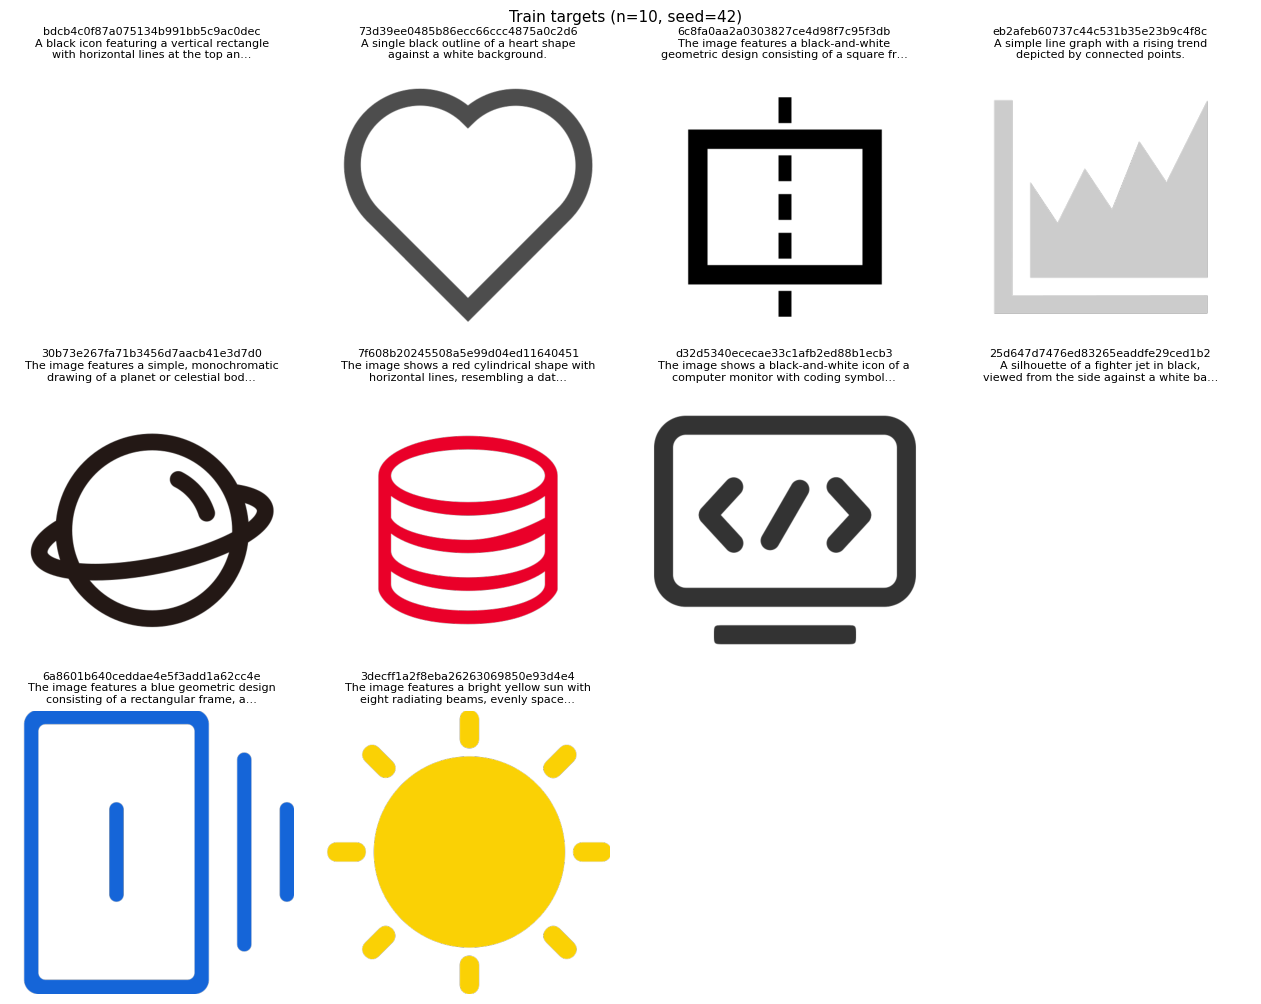

In [3]:
import textwrap
import sys
from math import ceil
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_DIR = Path('/content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL')
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

RAW_DIR = PROJECT_DIR / 'data' / 'raw'
TRAIN_CSV = RAW_DIR / 'train.csv'
N = 10
SEED = 42
RENDER_SIZE = 512
PROMPT_TITLE_CHARS = 80

from src.core.dataframe import choose_first_existing
from src.svg.rendering import render_svg_to_pil

train_df = pd.read_csv(TRAIN_CSV)
svg_col = choose_first_existing(train_df, ['svg', 'svg_code', 'target', 'label'], 'train_df')
prompt_col = choose_first_existing(train_df, ['prompt', 'description', 'text'], 'train_df')

n = min(int(N), len(train_df))
if n <= 0:
    raise ValueError('N must be positive and train CSV must be non-empty')
sample = train_df.sample(n=n, random_state=int(SEED)).reset_index(drop=True)

ncols = min(4, n)
nrows = int(ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 3.4 * nrows))
axes = axes.reshape(-1) if n > 1 else [axes]

for ax in axes[n:]:
    ax.axis('off')

for i in range(n):
    row = sample.iloc[i]
    ax = axes[i]
    img = render_svg_to_pil(str(row[svg_col]), output_width=RENDER_SIZE, output_height=RENDER_SIZE)
    ax.imshow(img)
    pid = str(row.get('id', i))
    ptxt = str(row[prompt_col])
    if len(ptxt) > PROMPT_TITLE_CHARS:
        ptxt = ptxt[: PROMPT_TITLE_CHARS - 1] + '…'
    title = f"{pid}\n{textwrap.fill(ptxt, width=44)}"
    ax.set_title(title, fontsize=8)
    ax.axis('off')

plt.suptitle(f'Train targets (n={n}, seed={SEED})', fontsize=11)
plt.tight_layout()
plt.show()

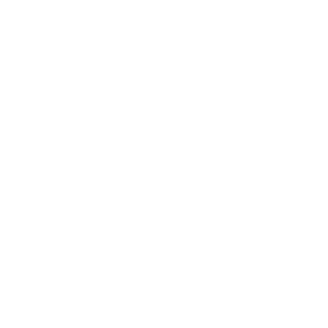

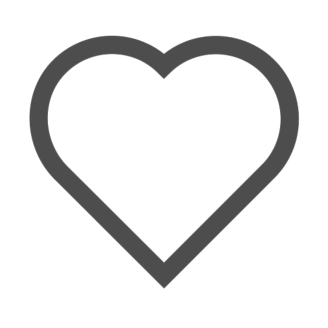

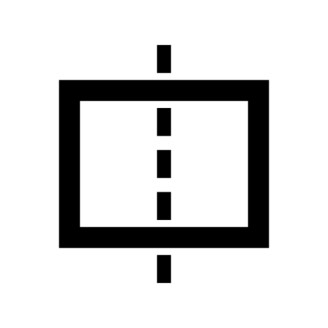

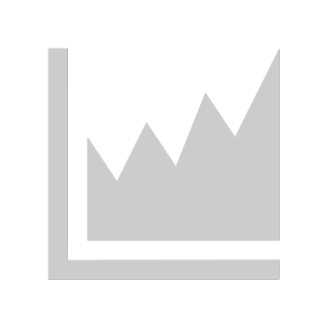

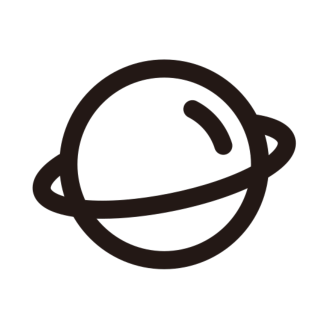

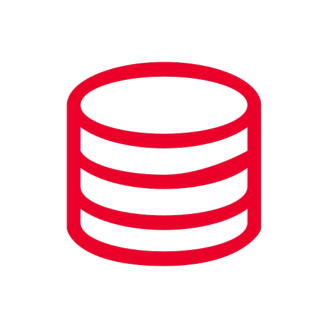

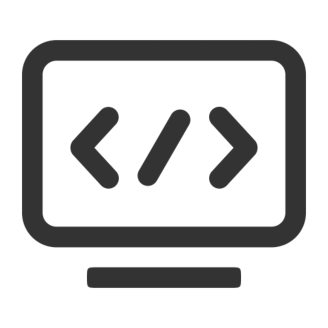

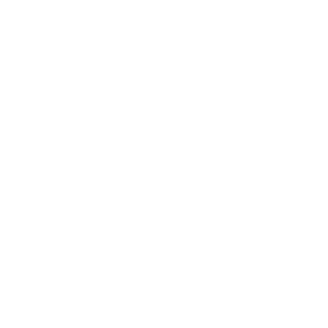

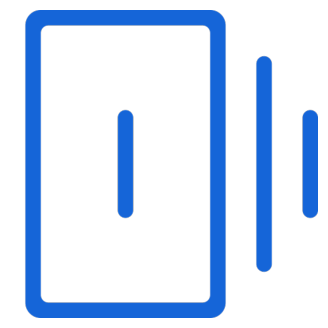

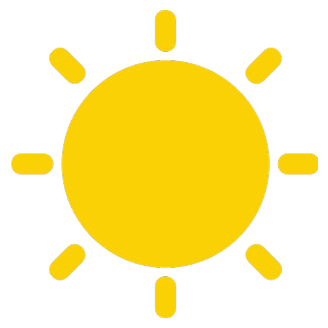

In [4]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_DIR = Path('/content/drive/MyDrive/DL_Midterm_Spring_2026_2/svg_project_DL')
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

RAW_DIR = PROJECT_DIR / 'data' / 'raw'
TRAIN_CSV = RAW_DIR / 'train.csv'
N = 10
SEED = 42
RENDER_SIZE = 512

from src.core.dataframe import choose_first_existing
from src.svg.rendering import render_svg_to_pil

train_df = pd.read_csv(TRAIN_CSV)
svg_col = choose_first_existing(train_df, ['svg', 'svg_code', 'target', 'label'], 'train_df')

n = min(int(N), len(train_df))
if n <= 0:
    raise ValueError('N must be positive and train CSV must be non-empty')

sample = train_df.sample(n=n, random_state=int(SEED)).reset_index(drop=True)

for i in range(n):
    row = sample.iloc[i]
    img = render_svg_to_pil(
        str(row[svg_col]),
        output_width=RENDER_SIZE,
        output_height=RENDER_SIZE
    )

    plt.figure(figsize=(4, 4))
    plt.imshow(img)
    plt.axis('off')
    plt.show()